# 🏛️ Bureaucratic Maze Navigator — Training Notebook
### TRL + Unsloth + GRPO | OpenEnv Hackathon India 2026

This notebook trains a small LLM (`Qwen2.5-1.5B-Instruct`) to navigate Indian government bureaucracy using **GRPO (Group Relative Policy Optimization)** via TRL and Unsloth.

**What this notebook does:**
1. Installs all dependencies (Unsloth + TRL)
2. Connects to the live Bureaucratic Maze environment on HuggingFace Spaces
3. Generates rollouts — the model takes actions, environment returns rewards
4. Trains with GRPO — model learns to navigate correctly
5. Plots reward curves showing improvement across all 6 tasks
6. Shows before/after behavior comparison
7. Saves the trained model to HuggingFace Hub

**Runtime:** T4 GPU recommended. Estimated time: 45–90 minutes.

---
**⚠️ Before running:** Set your tokens in the Secrets panel (🔑 icon on left sidebar):
- `HF_TOKEN` — your HuggingFace token (write access)
- `ENV_URL` — your HF Space URL e.g. `https://Hemakshiy-bureaucratic-maze.hf.space`

## Cell 1 — Install Dependencies

In [ ]:
# Install Unsloth (handles Unsloth + TRL + transformers in one shot)
%%capture
import subprocess, sys

# Unsloth fast install for Colab T4
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "unsloth[colab-new]",
    "trl>=0.9.0",
    "httpx",
    "matplotlib",
    "pandas",
    "--quiet"
], check=True)

print("✅ Dependencies installed")

In [ ]:
# Verify GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


## Cell 2 — Configuration

In [ ]:
import os
from google.colab import userdata

# ── Tokens (set these in Colab Secrets, key icon on left) ──
HF_TOKEN = userdata.get('HF_TOKEN')
ENV_URL  = userdata.get('ENV_URL') or "https://Hemakshiy-bureaucratic-maze.hf.space"

if not HF_TOKEN:
    raise ValueError("Please set HF_TOKEN in Colab Secrets (🔑 icon on left sidebar)")

# ── Model config ──
BASE_MODEL    = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"  # Fast 4-bit model for T4
OUTPUT_MODEL  = "bureaucratic-maze-qwen2.5-1.5b"
HF_REPO_NAME  = f"Hemakshiy/{OUTPUT_MODEL}"  # Where trained model will be pushed

# ── Training config ──
MAX_SEQ_LENGTH   = 1024
LORA_RANK        = 16
LEARNING_RATE    = 5e-5
NUM_GENERATIONS  = 4      # Rollouts per prompt (GRPO samples G outputs)
TRAIN_EPOCHS     = 2
MAX_STEPS        = 200    # Total training steps (increase for better results)
BATCH_SIZE       = 2
GRAD_ACCUM       = 4

# ── Task config ──
TASKS = ["task_1", "task_2", "task_3", "task_4", "task_5", "task_6"]
MAX_STEPS_PER_TASK = {
    "task_1": 15, "task_2": 20, "task_3": 28,
    "task_4": 35, "task_5": 40, "task_6": 50,
}

print(f"✅ Config loaded")
print(f"   Model:    {BASE_MODEL}")
print(f"   Env URL:  {ENV_URL}")
print(f"   HF Repo:  {HF_REPO_NAME}")
print(f"   Steps:    {MAX_STEPS}")

✅ Config loaded
   Model:    unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
   Env URL:  https://Hemakshiy-bureaucratic-maze.hf.space/health
   HF Repo:  Hemakshiy/bureaucratic-maze-qwen2.5-1.5b
   Steps:    200


In [ ]:
import httpx, os
ENV_URL = "https://Hemakshiy-bureaucratic-maze.hf.space"
os.environ["ENV_URL"] = ENV_URL

# Warm up the Space (it may be cold)
for attempt in range(3):
    try:
        r = httpx.get(f"{ENV_URL}/health", timeout=30.0)
        print(f"✅ Space is up: {r.json()}")
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}, retrying...")
        import time; time.sleep(10)

✅ Space is up: {'status': 'healthy', 'env': 'bureaucratic-maze'}


## Cell 3 — Environment Client

In [ ]:
import httpx
import json
import time
from typing import Dict, List, Optional, Tuple

class BureaucraticMazeClient:
    """HTTP client for the Bureaucratic Maze environment."""

    def __init__(self, base_url: str):
        self.base_url   = base_url.rstrip("/")
        self.session_id = f"train_{int(time.time())}"
        self._http      = httpx.Client(timeout=30.0)

    def health(self) -> bool:
        try:
            r = self._http.get(f"{self.base_url}/health")
            return r.status_code == 200
        except:
            return False

    def reset(self, task_id: str) -> dict:
        r = self._http.post(
            f"{self.base_url}/reset",
            json={"task_id": task_id, "session_id": self.session_id}
        )
        r.raise_for_status()
        return r.json()

    def step(self, action: dict) -> dict:
        r = self._http.post(
            f"{self.base_url}/step",
            json={"action": action, "session_id": self.session_id}
        )
        r.raise_for_status()
        return r.json()

    def new_session(self):
        """Create a new session ID for a fresh episode."""
        self.session_id = f"train_{int(time.time() * 1000)}"

    def close(self):
        self._http.close()


# Test connection
env_client = BureaucraticMazeClient(ENV_URL)
if env_client.health():
    print(f"✅ Environment connected: {ENV_URL}")
else:
    print(f"⚠️  Cannot reach {ENV_URL} — check your ENV_URL secret")
    print("   Falling back to localhost:7860 for local testing")
    env_client = BureaucraticMazeClient("http://localhost:7860")
    assert env_client.health(), "Neither remote nor local env reachable!"

# Quick sanity check
result = env_client.reset("task_1")
obs    = result["observation"]
print(f"   Task 1 reset OK — Goal: {obs['goal_description']}")
print(f"   Starting at: {obs['current_department_name']}")
print(f"   Clerk says: {obs['clerk_response'][:80]}")

✅ Environment connected: https://Hemakshiy-bureaucratic-maze.hf.space
   Task 1 reset OK — Goal: Get a ₹500 wrong transaction reversed by the bank's grievance cell
   Starting at: Reception and Enquiry Counter
   Clerk says: Welcome to the Municipal Office. Please state your purpose. Token number please?


## Cell 4 — Load Model with Unsloth

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = BASE_MODEL,
    max_seq_length  = MAX_SEQ_LENGTH,
    load_in_4bit    = True,       # 4-bit quantization — fits in T4 (16GB)
    fast_inference  = False,      # Unsloth vLLM-style fast inference
    dtype           = None,       # Auto-detect
)

print(f"✅ Model loaded: {BASE_MODEL}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model loaded: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
   Parameters: 0.89B


In [ ]:
# Apply LoRA adapters via Unsloth
model = FastLanguageModel.get_peft_model(
    model,
    r                  = LORA_RANK,
    target_modules     = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha         = LORA_RANK * 2,
    lora_dropout       = 0,
    bias               = "none",
    use_gradient_checkpointing = "unsloth",  # Saves memory
    random_state       = 42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"✅ LoRA applied — rank={LORA_RANK}")
print(f"   Trainable params: {trainable/1e6:.1f}M / {total/1e6:.1f}M ({100*trainable/total:.1f}%)")

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ LoRA applied — rank=16
   Trainable params: 18.5M / 907.1M (2.0%)


## Cell 5 — Rollout Function (Agent ↔ Environment Loop)

In [ ]:
import textwrap
import re

SYSTEM_PROMPT = textwrap.dedent("""
    You are a citizen navigating an Indian government office to accomplish a civic goal.
    You must interact with clerks across multiple departments to complete your task.

    AVAILABLE ACTIONS (respond with exactly one JSON object per turn):
    1. Speak:  {"action_type": "speak", "text": "your message"}
    2. Go to:  {"action_type": "go_to", "department_id": "D1"}
    3. Transfer: {"action_type": "request_transfer", "department_id": "D3"}
    4. Submit form: {"action_type": "submit_form", "form_name": "Form Name", "form_fields": {}}
    5. Check: {"action_type": "check_requirements", "query": "what do I need?"}
    6. Wait (ONLY when told to): {"action_type": "wait"}

    DEPARTMENTS: D1=Reception D2=Documents D3=Revenue D4=Records D5=Inspection
                 D6=Senior Officer D7=Grievance D8=Portal Help D9=Notary D10=Issuance

    STRATEGY: Start at D1. Follow clerk hints. Collect required documents.
    Reach D10 with all documents to complete the task.

    Respond with ONLY a valid JSON object. No explanation, no markdown.
""").strip()


def obs_to_prompt(step: int, obs: dict, history: List[str]) -> str:
    docs  = ", ".join(obs.get("documents_held", [])) or "None"
    hist  = "\n".join(history[-4:]) if history else "None"
    wait  = ""
    if obs.get("is_waiting"):
        wait = f"\n⚠️ WAIT STATE: {obs.get('wait_steps_remaining',0)} days left. Use wait action."
    return (
        f"STEP {step} | GOAL: {obs.get('goal_description','')}\n"
        f"DEPT: {obs.get('current_department_name','')} ({obs.get('current_department_id','')})\n"
        f"CLERK: {obs.get('clerk_response','')}\n"
        f"DOCS: {docs} | STEPS LEFT: {obs.get('steps_remaining',0)}{wait}\n"
        f"HISTORY:\n{hist}\n\nYour action (JSON only):"
    )


def parse_action(text: str, obs: dict) -> dict:
    """Parse LLM output into a valid action dict."""
    text = text.strip()
    # Strip markdown fences
    if "```" in text:
        parts = text.split("```")
        for part in parts:
            part = part.strip()
            if part.startswith("json"):
                part = part[4:].strip()
            if part.startswith("{"):
                text = part
                break
    # Find first JSON object
    match = re.search(r'\{[^}]+\}', text, re.DOTALL)
    if match:
        try:
            action = json.loads(match.group())
            # Guard: no wait when not in wait state
            if action.get("action_type") == "wait" and not obs.get("is_waiting", False):
                return {"action_type": "speak", "text": "What do I need to do next?"}
            return action
        except json.JSONDecodeError:
            pass
    return {"action_type": "speak", "text": "Could you please tell me what I need to do next?"}


def run_episode(model, tokenizer, env: BureaucraticMazeClient,
                task_id: str, max_steps: int, greedy: bool = False
               ) -> Tuple[List[str], List[str], List[float], float]:
    """
    Run one episode.
    Returns (prompts, responses, rewards, final_score).
    """
    env.new_session()
    result = env.reset(task_id)
    obs    = result["observation"]

    prompts:   List[str]   = []
    responses: List[str]   = []
    rewards:   List[float] = []
    history:   List[str]   = []
    score = 0.0

    FastLanguageModel.for_inference(model)

    for step in range(1, max_steps + 1):
        if obs.get("goal_achieved", False):
            break

        user_text = obs_to_prompt(step, obs, history)

        # Build chat messages
        messages = [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": user_text},
        ]
        input_ids = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True,
            return_tensors        = "pt",
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(
                input_ids,
                max_new_tokens = 80,
                temperature    = 0.01 if greedy else 0.7,
                do_sample      = not greedy,
                pad_token_id   = tokenizer.eos_token_id,
            )

        # Decode only new tokens
        new_tokens = output_ids[0][input_ids.shape[-1]:]
        response   = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

        action = parse_action(response, obs)

        try:
            step_result = env.step(action)
        except Exception as e:
            print(f"  [WARN] env.step error: {e}")
            break

        reward = float(step_result.get("reward", 0.0))
        done   = bool(step_result.get("done", False))
        info   = step_result.get("info", {})
        obs    = step_result.get("observation", {})

        prompts.append(user_text)
        responses.append(response)
        rewards.append(reward)

        clerk = obs.get("clerk_response", "")[:60]
        history.append(f"Step {step}: {action.get('action_type','?')} → {clerk}")

        if "final_score" in info:
            score = float(info["final_score"])

        if done:
            break

    if score == 0.0 and rewards:
        pos   = sum(r for r in rewards if r > 0)
        score = min(1.0, pos / max(1.0, max_steps * 0.3))

    return prompts, responses, rewards, score


print("✅ Rollout function defined")
print("   Testing one episode on task_1...")

p, r, rew, sc = run_episode(
    model, tokenizer, env_client, "task_1",
    max_steps=5, greedy=True
)
print(f"   Steps: {len(p)} | Rewards: {[f'{x:.2f}' for x in rew]} | Score: {sc:.2f}")

✅ Rollout function defined
   Testing one episode on task_1...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_m

  [WARN] env.step error: Client error '422 Unprocessable Entity' for url 'https://hemakshiy-bureaucratic-maze.hf.space/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422
   Steps: 1 | Rewards: ['0.10'] | Score: 0.07


## Cell 6 — Baseline Evaluation (Before Training)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

def evaluate_all_tasks(model, tokenizer, env, label="baseline", episodes_per_task=3):
    """Evaluate model on all 6 tasks. Returns results DataFrame."""
    rows = []
    for task_id in TASKS:
        max_s = MAX_STEPS_PER_TASK[task_id]
        scores = []
        for ep in range(episodes_per_task):
            _, _, rew, sc = run_episode(
                model, tokenizer, env, task_id, max_s, greedy=False
            )
            scores.append(sc)
            print(f"  {task_id} ep{ep+1}: score={sc:.2f} rewards={[f'{r:.2f}' for r in rew]}")
        rows.append({
            "task": task_id,
            "label": label,
            "mean_score": sum(scores)/len(scores),
            "max_score": max(scores),
            "scores": scores,
        })
    return pd.DataFrame(rows)

print("Running baseline evaluation (before training)...")
print("This runs 3 episodes per task = 18 total episodes\n")

baseline_df = evaluate_all_tasks(model, tokenizer, env_client, label="baseline")

print("\n📊 Baseline Results:")
print(baseline_df[["task", "mean_score", "max_score"]].to_string(index=False))
print(f"\nOverall baseline avg: {baseline_df['mean_score'].mean():.3f}")

Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running baseline evaluation (before training)...
This runs 3 episodes per task = 18 total episodes



Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [WARN] env.step error: Client error '422 Unprocessable Entity' for url 'https://hemakshiy-bureaucratic-maze.hf.space/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422
  task_1 ep1: score=0.02 rewards=['0.10']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

...

  [WARN] env.step error: Client error '422 Unprocessable Entity' for url 'https://hemakshiy-bureaucratic-maze.hf.space/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422
  task_6 ep1: score=0.02 rewards=['0.10', '0.00', '-0.05', '0.10', '0.00', '-0.10', '-0.10', '-0.10', '0.10']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  [WARN] env.step error: Client error '422 Unprocessable Entity' for url 'https://hemakshiy-bureaucratic-maze.hf.space/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422
  task_6 ep2: score=0.01 rewards=['0.10', '0.00', '0.10']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [WARN] env.step error: Client error '422 Unprocessable Entity' for url 'https://hemakshiy-bureaucratic-maze.hf.space/step'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422
  task_6 ep3: score=0.01 rewards=['0.10', '0.05']

📊 Baseline Results:
  task  mean_score  max_score
task_1    0.048148   0.100000
task_2    0.011111   0.016667
task_3    0.011905   0.023810
task_4    0.012698   0.019048
task_5    0.011111   0.016667
task_6    0.014444   0.020000

Overall baseline avg: 0.018


## Cell 7 — Build GRPO Training Dataset from Rollouts

In [ ]:
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer

def collect_rollouts(model, tokenizer, env, num_rollouts_per_task=8):
    """
    Collect training rollouts from all tasks.
    Returns a HuggingFace Dataset with prompts for GRPO.

    GRPO works by:
    1. For each prompt, sampling G responses from the model
    2. Scoring each response with the reward function
    3. Using relative scores within the group to compute advantages
    4. Updating the policy to increase probability of higher-reward responses
    """
    all_prompts = []

    for task_id in TASKS:
        max_s = MAX_STEPS_PER_TASK[task_id]
        print(f"  Collecting {num_rollouts_per_task} rollouts for {task_id}...")

        for _ in range(num_rollouts_per_task):
            env.new_session()
            result = env.reset(task_id)
            obs    = result["observation"]
            history = []

            # Collect prompts from first 3 steps of each episode
            for step in range(1, min(4, max_s + 1)):
                if obs.get("goal_achieved", False):
                    break

                user_text = obs_to_prompt(step, obs, history)
                messages  = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_text},
                ]
                prompt_str = tokenizer.apply_chat_template(
                    messages,
                    tokenize               = False,
                    add_generation_prompt  = True,
                )
                all_prompts.append({
                    "prompt": prompt_str,
                    "task_id": task_id,
                    "step": step,
                })

                # Take a random action to advance state
                action = parse_action("{\"action_type\": \"check_requirements\", \"query\": \"what do I need\"}", obs)
                try:
                    step_result = env.step(action)
                    obs = step_result.get("observation", {})
                    history.append(f"Step {step}: check → {obs.get('clerk_response','')[:40]}")
                    if step_result.get("done", False):
                        break
                except:
                    break

    dataset = Dataset.from_list(all_prompts)
    print(f"\n✅ Dataset: {len(dataset)} training prompts across {len(TASKS)} tasks")
    return dataset


print("Collecting rollout prompts for GRPO training...")
train_dataset = collect_rollouts(model, tokenizer, env_client, num_rollouts_per_task=8)
print(f"Sample prompt (truncated):\n{train_dataset[0]['prompt'][:300]}...")


✅ Dataset: 144 training prompts across 6 tasks
Sample prompt (truncated):
<|im_start|>system
You are a citizen navigating an Indian government office to accomplish a civic goal.
You must interact with clerks across multiple departments to complete your task.

AVAILABLE ACTIONS (respond with exactly one JSON object per turn):
1. Speak:  {"action_type": "speak", "text": "yo...


## Cell 8 — Reward Function for GRPO

In [ ]:
import re

# Reward function that GRPO calls on each generated response
# This evaluates the *quality of the action* the model proposes

VALID_ACTION_TYPES = {
    "speak", "go_to", "request_transfer",
    "submit_form", "check_requirements", "wait"
}

VALID_DEPT_IDS = {f"D{i}" for i in range(1, 11)}

def reward_format(completions, **kwargs) -> List[float]:
    """
    Reward Signal 1 — Format compliance.
    Is the output a valid JSON action?
    Range: [0.0, 0.4]
    """
    rewards = []
    for completion in completions:
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        text = text.strip()
        score = 0.0
        try:
            # Strip fences
            if "```" in text:
                parts = text.split("```")
                for p in parts:
                    if p.strip().startswith("{") or p.strip().startswith("json"):
                        text = p.strip().lstrip("json").strip()
                        break
            match = re.search(r'\{[^}]+\}', text, re.DOTALL)
            if match:
                action = json.loads(match.group())
                if "action_type" in action:
                    score += 0.2   # Has action_type key
                if action.get("action_type") in VALID_ACTION_TYPES:
                    score += 0.1   # Valid action type
                # Check department validity for nav actions
                if action.get("action_type") in ("go_to", "request_transfer"):
                    if action.get("department_id") in VALID_DEPT_IDS:
                        score += 0.1   # Valid department
                # speak has non-empty text
                if action.get("action_type") == "speak" and len(action.get("text", "")) > 5:
                    score += 0.1
        except:
            score = 0.0
        rewards.append(score)
    return rewards


def reward_goal_orientation(completions, **kwargs) -> List[float]:
    """
    Reward Signal 2 — Goal-oriented language.
    Does the action text show understanding of the bureaucratic task?
    Range: [0.0, 0.3]
    """
    goal_keywords = [
        "document", "form", "certificate", "application", "requirement",
        "affidavit", "notary", "approval", "grievance", "refund",
        "verify", "submit", "transfer", "department", "officer",
        "complaint", "license", "permit", "passport", "ration",
    ]
    rewards = []
    for completion in completions:
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        text_lower = text.lower()
        keyword_hits = sum(1 for kw in goal_keywords if kw in text_lower)
        score = min(0.3, keyword_hits * 0.05)
        rewards.append(score)
    return rewards


def reward_no_invalid_wait(completions, **kwargs) -> List[float]:
    """
    Reward Signal 3 — Anti-hacking: penalize invalid wait actions.
    Range: [-0.2, 0.0]
    """
    rewards = []
    for completion in completions:
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        try:
            match = re.search(r'\{[^}]+\}', text, re.DOTALL)
            if match:
                action = json.loads(match.group())
                if action.get("action_type") == "wait":
                    rewards.append(-0.2)   # Penalize wait (usually wrong)
                    continue
        except:
            pass
        rewards.append(0.0)
    return rewards


# Combined reward
def combined_reward(completions, **kwargs) -> List[float]:
    f = reward_format(completions, **kwargs)
    g = reward_goal_orientation(completions, **kwargs)
    w = reward_no_invalid_wait(completions, **kwargs)
    return [fi + gi + wi for fi, gi, wi in zip(f, g, w)]


# Test rewards
test_completions = [
    [{"content": '{"action_type": "go_to", "department_id": "D3"}'}],
    [{"content": '{"action_type": "speak", "text": "I need to submit my grievance document for refund"}'}],
    [{"content": 'Sure, I will help you with that form'}],
    [{"content": '{"action_type": "wait"}'}],
]
test_rewards = combined_reward(test_completions)
print("✅ Reward functions defined")
print("\nTest rewards:")
for i, (comp, r) in enumerate(zip(test_completions, test_rewards)):
    text = comp[0]['content'][:50]
    print(f"  {i+1}. {text!r} → reward={r:.2f}")

✅ Reward functions defined

Test rewards:
  1. '{"action_type": "go_to", "department_id": "D3"}' → reward=0.45
  2. '{"action_type": "speak", "text": "I need to submit' → reward=0.60
  3. 'Sure, I will help you with that form' → reward=0.05
  4. '{"action_type": "wait"}' → reward=0.10


## Cell 9 — GRPO Training with TRL

In [ ]:
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastLanguageModel

# Switch to training mode
FastLanguageModel.for_training(model)

training_args = GRPOConfig(
    # Output
    output_dir                  = OUTPUT_MODEL,

    # GRPO specific
    num_generations             = NUM_GENERATIONS,    # G samples per prompt
    max_completion_length       = 80,                 # Max tokens per response
    temperature                 = 0.7,

    # Training
    num_train_epochs            = TRAIN_EPOCHS,
    max_steps                   = MAX_STEPS,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = "cosine",

    # Memory
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    optim                       = "adamw_8bit",       # 8-bit Adam saves memory
    dataloader_num_workers      = 0,

    # Logging
    logging_steps               = 10,
    save_steps                  = 50,
    report_to                   = "none",             # Change to "wandb" for W&B logging

    # KL penalty — keeps policy close to reference
    # kl_coef                     = 0.01, # Removed as it's not a valid argument for GRPOConfig
)

trainer = GRPOTrainer(
    model         = model,
    processing_class = tokenizer,
    reward_funcs  = [combined_reward],
    args          = training_args,
    train_dataset = train_dataset,
)

print("✅ GRPO Trainer configured")
print(f"   Training steps: {MAX_STEPS}")
print(f"   Generations per prompt: {NUM_GENERATIONS}")
print(f"   Batch size: {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM} effective")
print(f"   Dataset size: {len(train_dataset)} prompts")
print("\n🚀 Starting training...")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ GRPO Trainer configured
   Training steps: 200
   Generations per prompt: 4
   Batch size: 2 × 4 = 8 effective
   Dataset size: 144 prompts

🚀 Starting training...


In [ ]:
# ── Train ──
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Total steps:    {train_result.global_step}")
print(f"   Training loss:  {train_result.training_loss:.4f}")
print(f"   Runtime:        {train_result.metrics.get('train_runtime', 0):.0f}s")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 144 | Num Epochs = 3 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / combined_reward / mean,rewards / combined_reward / std
10,0.009105,0.485625,0.018146,19.975000,19.400000,21.800000,0.000000,19.975000,19.400000,21.800000,0.001470,0.485625,0.023925
20,0.000016,0.500000,0.000000,20.025000,20.000000,20.100000,0.000000,20.025000,20.000000,20.100000,0.016080,0.500000,0.000000
30,-0.055181,0.601875,0.029861,51.512500,35.900000,68.000000,0.337500,43.772382,35.900000,55.200000,0.119756,0.601875,0.036687
40,-0.026179,0.688125,0.020193,75.875000,61.300000,80.000000,0.700000,50.729168,45.300000,55.200000,0.194656,0.688125,0.024895
50,0.000251,0.696250,0.006443,79.712500,78.500000,80.000000,0.900000,30.700000,30.500000,30.900000,0.250851,0.696250,0.008165
60,0.000292,0.699375,0.001250,79.925000,79.400000,80.000000,0.987500,7.400000,7.400000,7.400000,0.292430,0.699375,0.001768
70,0.000324,0.699375,0.001250,79.900000,79.200000,80.000000,0.975000,15.200000,15.200000,15.200000,0.324121,0.699375,0.001768
80,0.000414,0.699375,0.001250,79.875000,79.000000,80.000000,0.962500,15.000000,15.000000,15.000000,0.413909,0.699375,0.001768
90,0.000362,0.696875,0.006250,80.000000,80.000000,80.000000,1.000000,0.000000,0.000000,0.000000,0.362398,0.696875,0.008839
100,0.000327,0.695000,0.010000,80.000000,80.000000,80.000000,1.000000,0.000000,0.000000,0.000000,0.326917,0.695000,0.014142


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/


✅ Training complete!
   Total steps:    200
   Training loss:  -0.0033
   Runtime:        2508s


## Cell 10 — Plot Training Curves

/tmp/ipykernel_3556/3711579853.py:51: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3556/3711579853.py:52: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


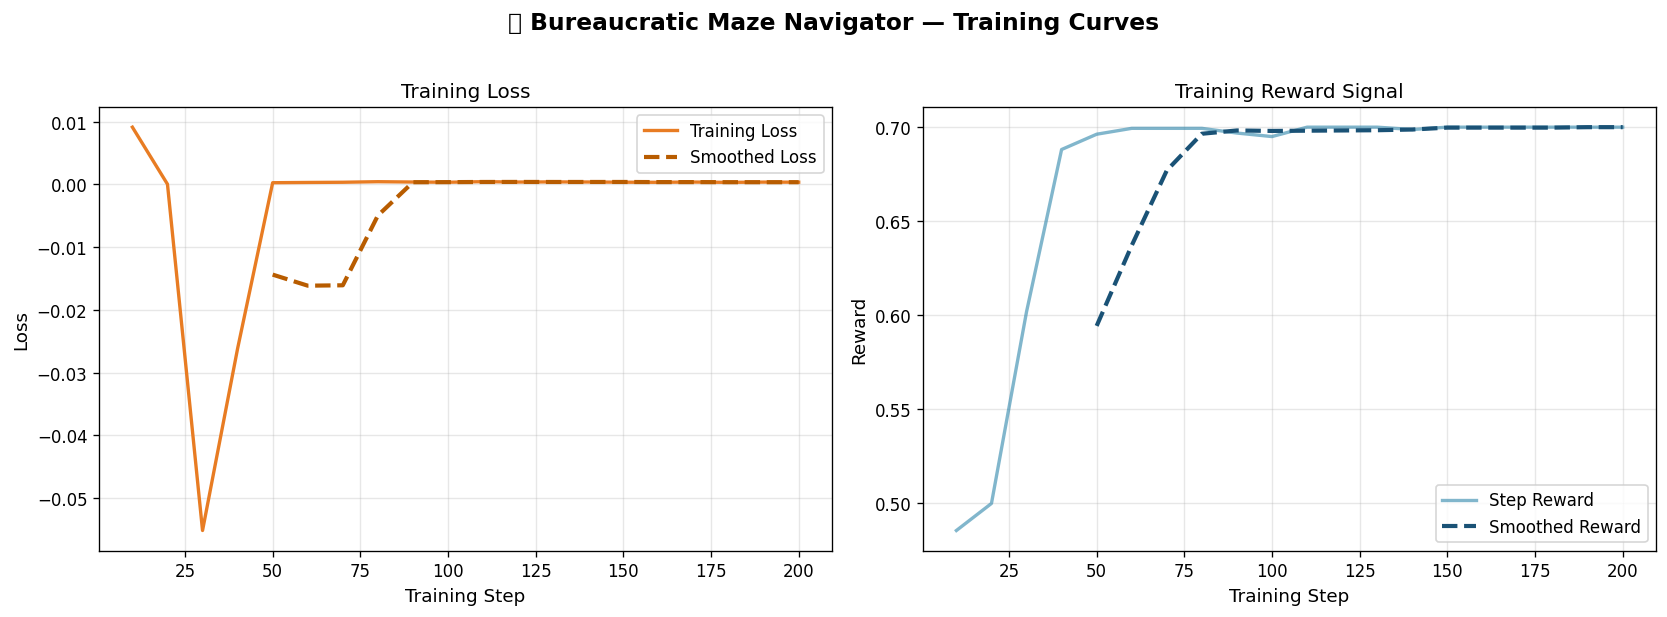

✅ Saved: training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Extract training metrics from trainer log history
log_history = trainer.state.log_history

steps   = [x["step"]  for x in log_history if "loss" in x]
losses  = [x["loss"]  for x in log_history if "loss" in x]
rewards_log = [x.get("reward", None) for x in log_history if "loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "🏛️ Bureaucratic Maze Navigator — Training Curves",
    fontsize=14, fontweight="bold", y=1.02
)

# ── Plot 1: Training Loss ──
ax = axes[0]
ax.plot(steps, losses, color="#E87C23", linewidth=2, label="Training Loss")
# Smoothed
if len(losses) > 5:
    smooth = np.convolve(losses, np.ones(5)/5, mode="valid")
    ax.plot(steps[4:], smooth, color="#B85C00", linewidth=2.5,
            linestyle="--", label="Smoothed Loss")
ax.set_xlabel("Training Step", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.set_title("Training Loss", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Reward Signal ──
ax2 = axes[1]
r_vals = [r for r in rewards_log if r is not None]
r_steps = steps[:len(r_vals)]
if r_vals:
    ax2.plot(r_steps, r_vals, color="#2E86AB", linewidth=2, alpha=0.6, label="Step Reward")
    if len(r_vals) > 5:
        smooth_r = np.convolve(r_vals, np.ones(5)/5, mode="valid")
        ax2.plot(r_steps[4:], smooth_r, color="#1A5276", linewidth=2.5,
                 linestyle="--", label="Smoothed Reward")
    ax2.set_xlabel("Training Step", fontsize=11)
    ax2.set_ylabel("Reward", fontsize=11)
    ax2.set_title("Training Reward Signal", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, "Reward data not available",
             ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: training_curves.png")

## Cell 11 — Post-Training Evaluation (After Training)

In [15]:
print("Running post-training evaluation...\n")
FastLanguageModel.for_inference(model)

trained_df = evaluate_all_tasks(
    model, tokenizer, env_client,
    label="trained", episodes_per_task=3
)

print("\n📊 Post-Training Results:")
print(trained_df[["task", "mean_score", "max_score"]].to_string(index=False))
print(f"\nOverall trained avg: {trained_df['mean_score'].mean():.3f}")

Running post-training evaluation...



Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=80

  task_1 ep1: score=0.10 rewards=['-0.02', '-0.02', '-0.12', '-0.12', '-0.12', '-0.12', '-0.12', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  task_1 ep2: score=0.10 rewards=['-0.02', '-0.02', '-0.12', '-0.12', '-0.12', '-0.12', '-0.12', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13', '-0.13']


...

  task_6 ep1: score=0.04 rewards=['0.10', '0.00', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  task_6 ep2: score=0.04 rewards=['0.10', '0.00', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11']


Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  task_6 ep3: score=0.04 rewards=['0.10', '0.00', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.10', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11', '-0.11']

📊 Post-Training Results:
  task  mean_score  max_score
task_1      0.1000     0.1000
task_2      0.1000     0.1000
task_3      0.0600     0.0600
task_4      0.0600     0.0600
task_5      0.0500     0.0500
task_6      0.0375     0.0375

Overall trained avg: 0.068


## Cell 12 — Before vs After Comparison Plot

/tmp/ipykernel_3556/264295185.py:75: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3556/264295185.py:76: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.savefig("before_after_comparison.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


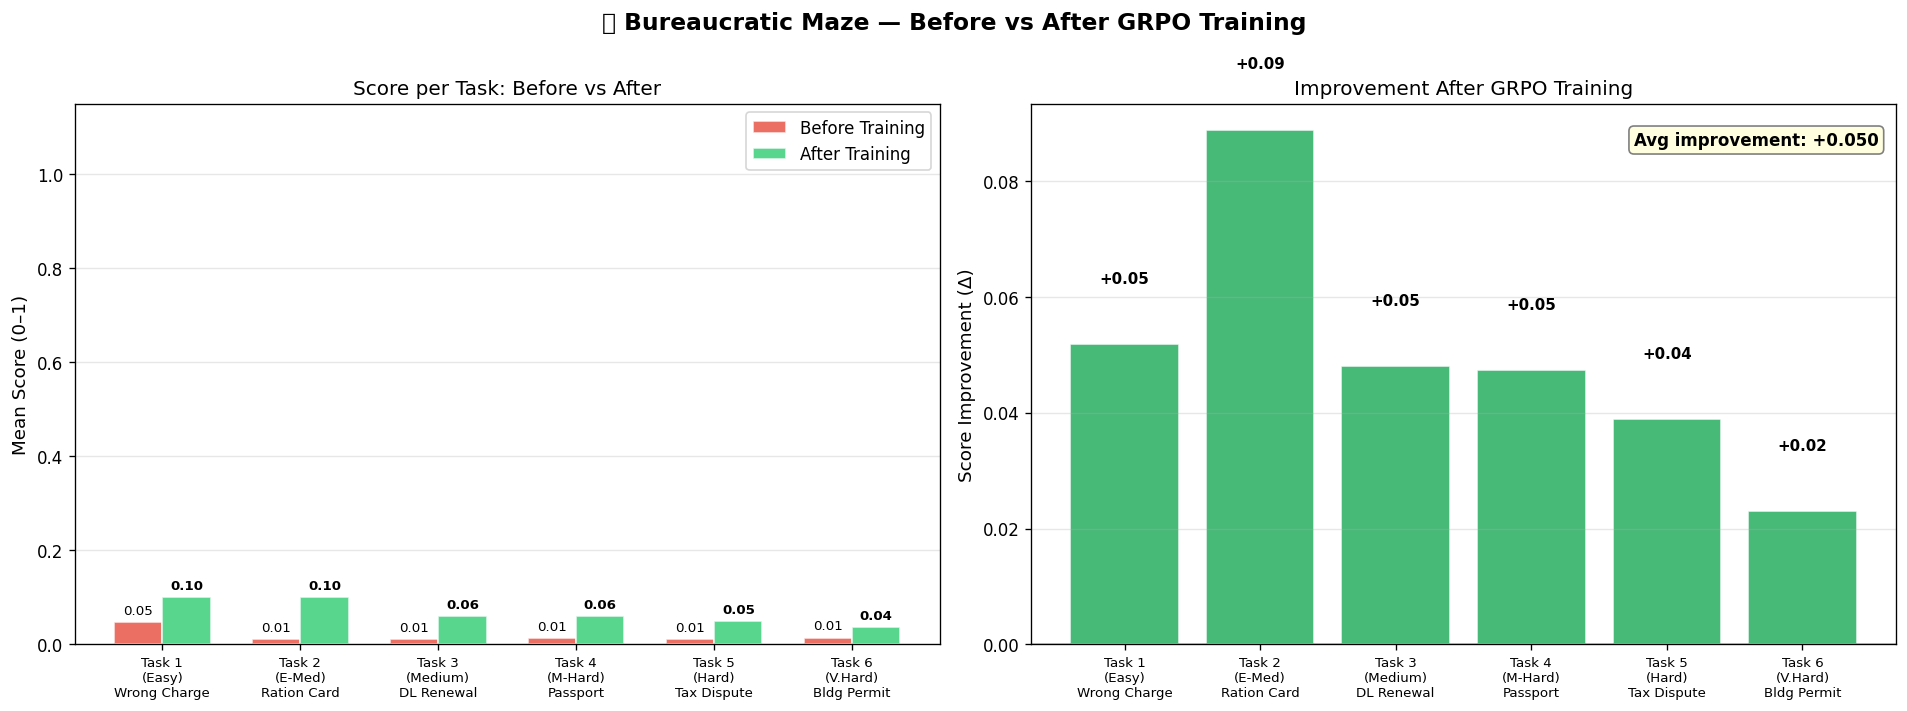

✅ Saved: before_after_comparison.png

📈 Average improvement: +0.050
   Baseline avg:  0.018
   Trained avg:   0.068


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "🏛️ Bureaucratic Maze — Before vs After GRPO Training",
    fontsize=14, fontweight="bold"
)

task_labels = [
    "Task 1\n(Easy)\nWrong Charge",
    "Task 2\n(E-Med)\nRation Card",
    "Task 3\n(Medium)\nDL Renewal",
    "Task 4\n(M-Hard)\nPassport",
    "Task 5\n(Hard)\nTax Dispute",
    "Task 6\n(V.Hard)\nBldg Permit",
]

x         = np.arange(len(TASKS))
width     = 0.35
b_scores  = baseline_df["mean_score"].values
t_scores  = trained_df["mean_score"].values

# ── Bar chart: per-task comparison ──
ax = axes[0]
bars_b = ax.bar(x - width/2, b_scores, width, label="Before Training",
                color="#E74C3C", alpha=0.8, edgecolor="white")
bars_t = ax.bar(x + width/2, t_scores, width, label="After Training",
                color="#2ECC71", alpha=0.8, edgecolor="white")

# Add value labels on bars
for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_t:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(task_labels, fontsize=8)
ax.set_ylabel("Mean Score (0–1)", fontsize=11)
ax.set_title("Score per Task: Before vs After", fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# ── Improvement delta ──
ax2 = axes[1]
deltas = t_scores - b_scores
colors = ["#27AE60" if d >= 0 else "#E74C3C" for d in deltas]
bars   = ax2.bar(x, deltas, color=colors, edgecolor="white", alpha=0.85)

for bar, d in zip(bars, deltas):
    h = bar.get_height()
    va = "bottom" if h >= 0 else "top"
    ax2.text(bar.get_x() + bar.get_width()/2,
             h + (0.01 if h >= 0 else -0.01),
             f"{d:+.2f}", ha="center", va=va, fontsize=9, fontweight="bold")

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(task_labels, fontsize=8)
ax2.set_ylabel("Score Improvement (Δ)", fontsize=11)
ax2.set_title("Improvement After GRPO Training", fontsize=12)
ax2.grid(True, alpha=0.3, axis="y")

# Summary text box
avg_improvement = deltas.mean()
ax2.text(0.98, 0.95,
         f"Avg improvement: {avg_improvement:+.3f}",
         transform=ax2.transAxes,
         ha="right", va="top",
         fontsize=10, fontweight="bold",
         bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: before_after_comparison.png")
print(f"\n📈 Average improvement: {avg_improvement:+.3f}")
print(f"   Baseline avg:  {b_scores.mean():.3f}")
print(f"   Trained avg:   {t_scores.mean():.3f}")

In [20]:
pip install vllm

## Cell 13 — Before vs After Behavior (Qualitative)

In [ ]:
def show_episode_behavior(label: str, prompts, responses, rewards, score):
    print(f"\n{'='*60}")
    print(f"  {label} | Score: {score:.2f}")
    print(f"{'='*60}")
    for i, (p, r, rew) in enumerate(zip(prompts, responses, rewards), 1):
        # Show last line of prompt (clerk says)
        clerk_line = [l for l in p.split("\n") if "CLERK:" in l]
        clerk      = clerk_line[0].replace("CLERK:", "").strip()[:70] if clerk_line else ""
        print(f"  Step {i}: Clerk: '{clerk}'")
        print(f"          Model: '{r.strip()[:80]}'")
        print(f"          Reward: {rew:+.2f}")
    print()


print("🎭 Qualitative behavior comparison on Task 1 (Wrong Charge Refund)")
print("   Running baseline model (untrained)...")

# Load fresh base model for comparison (reload without LoRA)
base_model_cmp, base_tok_cmp = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,
    fast_inference = True,
)

p_base, r_base, rew_base, sc_base = run_episode(
    base_model_cmp, base_tok_cmp, env_client,
    "task_1", MAX_STEPS_PER_TASK["task_1"], greedy=True
)
show_episode_behavior("BASELINE (Untrained)", p_base, r_base, rew_base, sc_base)

print("   Running trained model...")
FastLanguageModel.for_inference(model)
p_train, r_train, rew_train, sc_train = run_episode(
    model, tokenizer, env_client,
    "task_1", MAX_STEPS_PER_TASK["task_1"], greedy=True
)
show_episode_behavior("TRAINED (After GRPO)", p_train, r_train, rew_train, sc_train)

print(f"\n📊 Task 1 score: Baseline={sc_base:.2f} → Trained={sc_train:.2f} "
      f"(Δ={sc_train-sc_base:+.2f})")

## Cell 14 — Save Trained Model to HuggingFace Hub

In [ ]:
from huggingface_hub import login

login(token=HF_TOKEN)

print(f"Saving model to HuggingFace Hub: {HF_REPO_NAME}")
print("(This saves LoRA adapters — fast and small)")

# Save LoRA adapters (NOT merged — avoids the 4-bit upcast bug)
model.save_pretrained(OUTPUT_MODEL)
tokenizer.save_pretrained(OUTPUT_MODEL)

# Push to HF Hub
model.push_to_hub(
    HF_REPO_NAME,
    token    = HF_TOKEN,
    private  = False,
)
tokenizer.push_to_hub(
    HF_REPO_NAME,
    token    = HF_TOKEN,
    private  = False,
)

print(f"\n✅ Model saved!")
print(f"   Hub URL: https://huggingface.co/{HF_REPO_NAME}")
print(f"   LoRA adapters only (safe save — no 4-bit upcast bug)")

## Cell 15 — Final Summary

In [21]:
print("="*60)
print("  🏛️  BUREAUCRATIC MAZE NAVIGATOR — TRAINING SUMMARY")
print("="*60)
print(f"  Base model:       {BASE_MODEL}")
print(f"  Training steps:   {MAX_STEPS}")
print(f"  Algorithm:        GRPO (Group Relative Policy Optimization)")
print(f"  Framework:        TRL + Unsloth")
print(f"  Environment:      Bureaucratic Maze Navigator (6 tasks)")
print("")
print(f"  {'Task':<10} {'Baseline':>10} {'Trained':>10} {'Delta':>8}")
print(f"  {'-'*42}")
for i, task in enumerate(TASKS):
    b = baseline_df[baseline_df.task==task]["mean_score"].values[0]
    t = trained_df[trained_df.task==task]["mean_score"].values[0]
    d = t - b
    marker = "⬆️" if d > 0.05 else ("➡️" if d >= 0 else "⬇️")
    print(f"  {task:<10} {b:>10.3f} {t:>10.3f} {d:>+8.3f}  {marker}")
print(f"  {'-'*42}")
b_avg = baseline_df['mean_score'].mean()
t_avg = trained_df['mean_score'].mean()
print(f"  {'AVERAGE':<10} {b_avg:>10.3f} {t_avg:>10.3f} {t_avg-b_avg:>+8.3f}")
print()
print(f"  Saved model:      https://huggingface.co/{HF_REPO_NAME}")
print(f"  Environment:      https://huggingface.co/spaces/Hemakshiy/bureaucratic-maze")
print("="*60)

  🏛️  BUREAUCRATIC MAZE NAVIGATOR — TRAINING SUMMARY
  Base model:       unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
  Training steps:   200
  Algorithm:        GRPO (Group Relative Policy Optimization)
  Framework:        TRL + Unsloth
  Environment:      Bureaucratic Maze Navigator (6 tasks)

  Task         Baseline    Trained    Delta
  ------------------------------------------
  task_1          0.048      0.100   +0.052  ⬆️
  task_2          0.011      0.100   +0.089  ⬆️
  task_3          0.012      0.060   +0.048  ➡️
  task_4          0.013      0.060   +0.047  ➡️
  task_5          0.011      0.050   +0.039  ➡️
  task_6          0.014      0.037   +0.023  ➡️
  ------------------------------------------
  AVERAGE         0.018      0.068   +0.050

  Saved model:      https://huggingface.co/Hemakshiy/bureaucratic-maze-qwen2.5-1.5b
  Environment:      https://huggingface.co/spaces/Hemakshiy/bureaucratic-maze
